#### ResNet Without overfitting

Epoch 1/50
100/100 [==============================] - 121s 1s/step - loss: 0.8245 - accuracy: 0.5169 - val_loss: 0.7333 - val_accuracy: 0.5000 - lr: 1.0000e-04
Epoch 2/50
100/100 [==============================] - 109s 1s/step - loss: 0.7759 - accuracy: 0.5313 - val_loss: 0.7702 - val_accuracy: 0.5000 - lr: 1.0000e-04
Epoch 3/50
100/100 [==============================] - 111s 1s/step - loss: 0.7757 - accuracy: 0.5247 - val_loss: 0.6731 - val_accuracy: 0.7071 - lr: 1.0000e-04
Epoch 4/50
100/100 [==============================] - 108s 1s/step - loss: 0.7206 - accuracy: 0.5647 - val_loss: 0.7015 - val_accuracy: 0.5000 - lr: 1.0000e-04
Epoch 5/50
100/100 [==============================] - 98s 977ms/step - loss: 0.6891 - accuracy: 0.5782 - val_loss: 0.6724 - val_accuracy: 0.5286 - lr: 1.0000e-04
Epoch 6/50
100/100 [==============================] - 96s 961ms/step - loss: 0.6845 - accuracy: 0.5857 - val_loss: 0.6649 - val_accuracy: 0.5357 - lr: 1.0000e-04
Epoch 7/50
100/100 [================

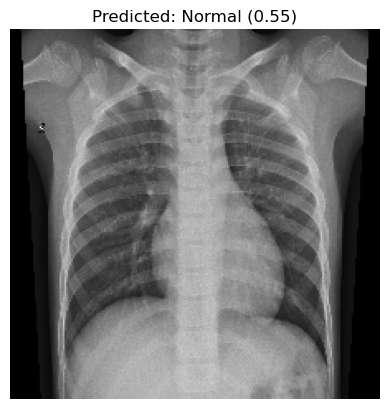

Predicted Class: Normal
Confidence Score: 0.55
1/1 [==============================] - 1s 575ms/step

Classification Report on Test Data:
               precision    recall  f1-score   support

      Normal       0.71      0.52      0.60       172
   Pneumonia       0.78      0.89      0.83       328

    accuracy                           0.76       500
   macro avg       0.74      0.71      0.72       500
weighted avg       0.76      0.76      0.75       500



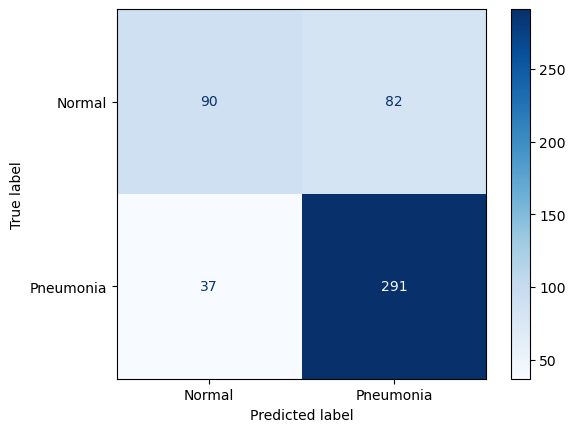

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing import image

# Define Paths
data_dir_train = "C:/Users/amazm/University/Personal Projects/Pneumonia Detection/chest_xray/train"
data_dir_validation = "C:/Users/amazm/University/Personal Projects/Pneumonia Detection/chest_xray/val"
data_dir_test = "C:/Users/amazm/University/Personal Projects/Pneumonia Detection/chest_xray/test"

# Image Properties
img_height, img_width = 224, 224
batch_size = 32

# Class Labels
class_names = ["Normal", "Pneumonia"]

def load_images_from_directory(directory):
    images, labels = [], []
    normal_label, pneumonia_label = 0, 1  # Assign numerical labels
    
    for filepath in Path(directory).rglob("*.jpeg"):
        img = image.load_img(filepath, target_size=(img_height, img_width))
        img_array = image.img_to_array(img) / 255.0  # Normalize image
        images.append(img_array)
        
        # Assign labels explicitly
        if "NORMAL" in str(filepath.parent):
            labels.append(normal_label)
        else:
            labels.append(pneumonia_label)

    return np.array(images), np.array(labels)

# Load Train, Validation, and Test Data
X_train, y_train = load_images_from_directory(data_dir_train)
X_val, y_val = load_images_from_directory(data_dir_validation)
X_test, y_test = load_images_from_directory(data_dir_test)

# Convert to TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size).shuffle(1000)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

# Load Pretrained ResNet50 Model
base_model = tf.keras.applications.ResNet50(
    input_shape=(img_height, img_width, 3),
    include_top=False,  
    weights='imagenet'
)
base_model.trainable = False  # Freeze layers for transfer learning

# Define Model
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')  
])

# Compile Model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Define Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=0.00001)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Train Model
epochs = 50  
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=[reduce_lr, early_stopping])

# Evaluate Model on Test Data
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Load and Predict on New Image
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)  
    img_array = np.expand_dims(img_array, axis=0)  
    img_array /= 255.0  

    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)[0]  
    confidence = np.max(predictions)  

    plt.imshow(img)
    plt.title(f"Predicted: {class_names[predicted_class]} ({confidence:.2f})")
    plt.axis("off")
    plt.show()
    print(f"Predicted Class: {class_names[predicted_class]}")
    print(f"Confidence Score: {confidence:.2f}")

# Test Prediction on a Sample Image
test_img_path = "C:/Users/amazm/University/Personal Projects/Pneumonia Detection/chest_xray/test/NORMAL/IM-0103-0001.jpeg"
predict_image(test_img_path)

# Model Evaluation on Test Data
y_test_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_test_pred.extend(np.argmax(predictions, axis=1))

# Print Classification Report
print("\nClassification Report on Test Data:\n", classification_report(y_test, y_test_pred, target_names=class_names))

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp_test.plot(cmap=plt.cm.Blues)
plt.show()


In [10]:
model.save('pneumonia_detection_model.h5')
print("Model saved successfully as 'pneumonia_detection_model.h5'")

Model saved successfully as 'pneumonia_detection_model.h5'


1/1 [==============================] - 0s 72ms/step


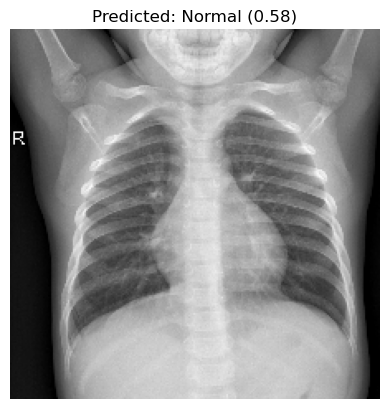

Predicted Class: Normal
Confidence Score: 0.58


In [5]:
test_img_path = "C:/Users/amazm/University/Personal Projects/Pneumonia Detection/chest_xray/test/NORMAL/IM-0103-0001.jpeg"
predict_image(test_img_path)

1/1 [==============================] - 0s 65ms/step


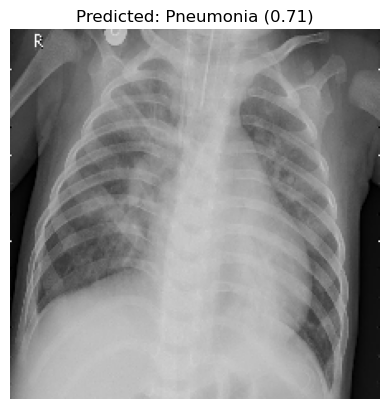

Predicted Class: Pneumonia
Confidence Score: 0.71


In [8]:
test_img_path = "C:/Users/amazm/University/Personal Projects/Pneumonia Detection/chest_xray/test/PNEUMONIA/person87_bacteria_433.jpeg"
predict_image(test_img_path)